# Importing library

In [1]:
import pandas as pd
import numpy as np
import string

# Importing file and printing the first five contant of the datase

In [2]:
Weather_data = pd.read_csv("austin_weather.csv")
Weather_data.head()

,Date,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,...,SeaLevelPressureAvgInches,SeaLevelPressureLowInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches,Events
0,2013-12-21,74,60,45,67,49,43,93,75,57,...,29.68,29.59,10,7,2,20,4,31,0.46,"Rain , Thunderstorm"
1,2013-12-22,56,48,39,43,36,28,93,68,43,...,30.13,29.87,10,10,5,16,6,25,0,
2,2013-12-23,58,45,32,31,27,23,76,52,27,...,30.49,30.41,10,10,10,8,3,12,0,
3,2013-12-24,61,46,31,36,28,21,89,56,22,...,30.45,30.3,10,10,7,12,4,20,0,
4,2013-12-25,58,50,41,44,40,36,86,71,56,...,30.33,30.27,10,10,7,10,2,16,T,


# Removing unnecessary columns 

In [3]:
clean = ["Events", "Date", "SeaLevelPressureLowInches"]
Weather_data_clean = Weather_data.drop(columns=clean)

# Removing Non-numeric data from the dataset and printing the first five data from it

In [4]:
Weather_data_clean = Weather_data_clean.replace("T",0)
Weather_data_clean = Weather_data_clean.replace("-",0)
Weather_data_clean.head()

,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,SeaLevelPressureHighInches,SeaLevelPressureAvgInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches
0,74,60,45,67,49,43,93,75,57,29.86,29.68,10,7,2,20,4,31,0.46
1,56,48,39,43,36,28,93,68,43,30.41,30.13,10,10,5,16,6,25,0
2,58,45,32,31,27,23,76,52,27,30.56,30.49,10,10,10,8,3,12,0
3,61,46,31,36,28,21,89,56,22,30.56,30.45,10,10,7,12,4,20,0
4,58,50,41,44,40,36,86,71,56,30.41,30.33,10,10,7,10,2,16,0


# Exporting the data set to another csv file 

In [5]:
Weather_data_clean.to_csv("Weather_data_clean_final.csv")

# Importing  required libraries

In [55]:
import sklearn as sk
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as  plt

In [11]:
Weather_data = pd.read_csv("Weather_data_clean_final.csv")
Weather_data.head()

,Unnamed: 0,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,SeaLevelPressureHighInches,SeaLevelPressureAvgInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches
0,0,74,60,45,67,49,43,93,75,57,29.86,29.68,10,7,2,20,4,31,0.46
1,1,56,48,39,43,36,28,93,68,43,30.41,30.13,10,10,5,16,6,25,0.00
2,2,58,45,32,31,27,23,76,52,27,30.56,30.49,10,10,10,8,3,12,0.00
3,3,61,46,31,36,28,21,89,56,22,30.56,30.45,10,10,7,12,4,20,0.00
4,4,58,50,41,44,40,36,86,71,56,30.41,30.33,10,10,7,10,2,16,0.00


# Creating labels in the X, Y

In [14]:
X = Weather_data.drop(["PrecipitationSumInches"],axis = 1)
Y = Weather_data["PrecipitationSumInches"]
Y = Y.values.reshape(-1,1)

array([[0.46],
       [0.  ],
       [0.  ],
       ...,
       [0.  ],
       [0.  ],
       [0.  ]], shape=(1319, 1))

In [19]:
day_index = 798
days = [i for i in range(Y.size)]

In [21]:
# initislise the linear reression classifier
clf = LinearRegression()
# train the classifier 
clf.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Ploting a Graph


The Precipitation trend graph: 


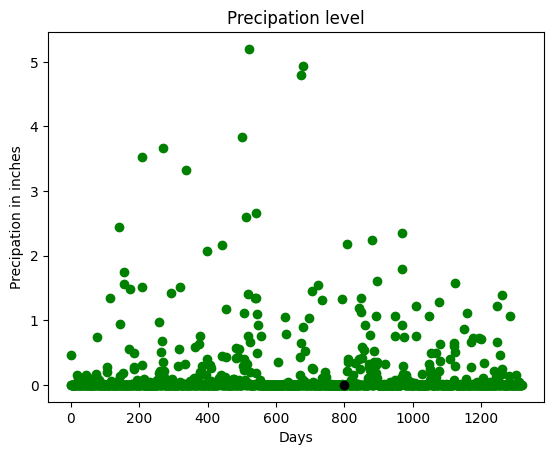

In [53]:
print("The Precipitation trend graph: ")
plt.scatter(days,Y,color = "g")
plt.scatter(days[day_index], Y[day_index], color = "k")
plt.title("Precipation level")
plt.xlabel("Days")
plt.ylabel("Precipation in inches")
plt.show()
x_vis = X.filter(["TempAvgF","DewPointAvgF","HumidityAvgPercent","SeaLevelPressureAvgInches","VisibilityAvgMiles","WindAvgMPH"])

# Visualizating the graph with Precipation as Y axis and other parameters 

The Pricipitation vs Attributed trends graph:


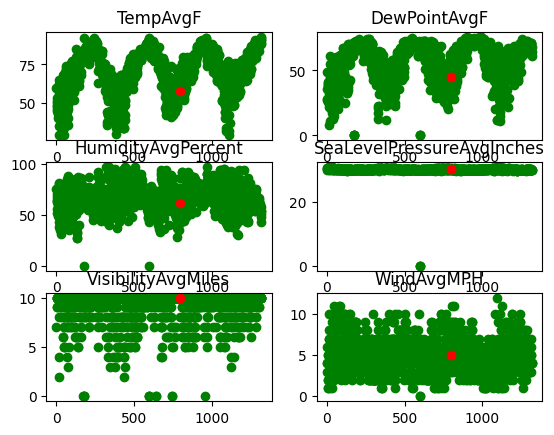

In [54]:
print("The Pricipitation vs Attributed trends graph:")

for i in range(x_vis.columns.size):
    plt.subplot(3,2,i+1)
    plt.scatter(days,x_vis[x_vis.columns.values[i][:100]],color = "g")
    plt.scatter(days[day_index],x_vis[x_vis.columns.values[i]][day_index], color = 'r')
    plt.title(x_vis.columns.values[i])
plt.show()    